# 2025-04-30 Alpha diversity

## Summary

This notebooks considers the analysis of the alpha-diversity in our libraries mapped against the GTDB.

## Data

- Our libraries, after removing reads not mapped at species level, grouping by species, and filtering those with less than 10 reads.

## Analysis

- **Species richness**. Simple number of species.
- **Shannon Entropy**. 
- **Chao1**. 
- **Faith's PD**. It requires the GTDB phylogenetic tree.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.spatial.distance import braycurtis
from sklearn.decomposition import PCA
from scipy.stats import entropy
import networkx as nx 
from scipy.stats import kruskal
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

In [27]:
libraries = pd.read_json("../results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json").rename(columns={'taxid': "gtdb_id"}).dropna(subset=['species'])

### Species richness

In [28]:
print("The total number of libraries with at least 1 hit is : ", len(libraries['library'].unique()))

The total number of libraries with at least 1 hit is :  316


In [29]:
print("The overall species richness in the whole experiment is : ", len(libraries['gtdb_id'].unique()))

The overall species richness in the whole experiment is :  2407


#### Species richness by site

1. Making a list of unique `[species, habitat, site]`
2. Counting the number of species rows that showed up in the previous operation.

#### Calculation

In [30]:
species_richness_by_site = libraries.value_counts(
    ['Site_code', 'Habitat', 'gtdb_id']
).reset_index().value_counts(
    ['Habitat', 'Site_code']
).reset_index()

species_richness_by_site['index'] = np.arange(len(species_richness_by_site))
species_richness_by_site

,Habitat,Site_code,count,index
0,Oak,Q1,746,0
1,Edge,L3,691,1
2,Wasteland,E3,614,2
3,Oak,Q2,604,3
4,Wasteland,E4,597,4
5,Wasteland,E2,538,5
6,Oak,Q4,508,6
7,Wasteland,E1,495,7
8,Edge,L1,474,8
9,Edge,L2,457,9


#### Plots

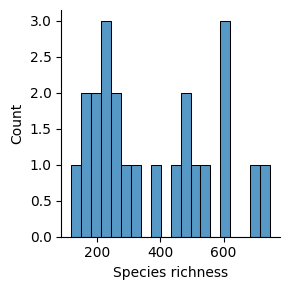

In [31]:
g = sns.displot(data=species_richness_by_site, x='count', height=3.0, bins=20)
g.set_ylabels("Count")
g.set_xlabels("Species richness")
g.savefig("../figures/histplot.species_richness-site.svg")
g.savefig("../figures/histplot.species_richness-site.png", dpi=300)

**Figure 1**. Histogram. Distribution of species hits per sample. 
- Not normal-like. 
- Possibly bimodal.

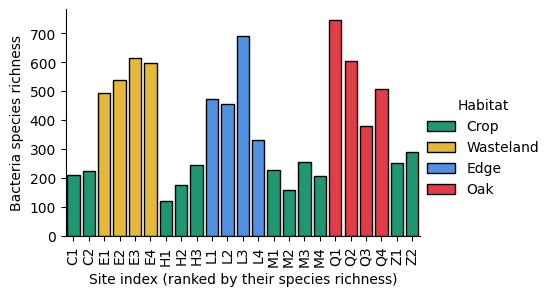

In [32]:
g = sns.catplot(species_richness_by_site.sort_values(by='Site_code'), x='Site_code', y='count', height=3.0, aspect=1.5, kind='bar', hue='Habitat', palette=habitat_palette, edgecolor='black')
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site index (ranked by their species richness)")
g.set_xticklabels(rotation=90)
g.savefig("../figures/catplot.unsorted.species_richness-site.svg")
g.savefig("../figures/catplot.unsorted.species_richness-site.png", dpi=300)

**Figure 2**. Sorted barplot on the bacteria species richness of each site, colored by the habitat.

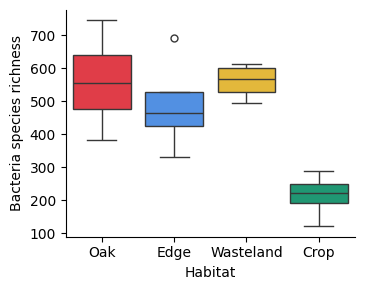

In [33]:
g = sns.catplot(data=species_richness_by_site, x='Habitat', y='count', kind='box', aspect=1.25, height=3.0, hue='Habitat', palette=habitat_palette)
g.set_ylabels("Bacteria species richness")
g.savefig("../figures/boxplot.species_richness-site-byhabitat.svg")

**Figure 3**. Boxplot on the site richness, grouped and coloured by habitat.

#### Statistics

Our hypothesis:
- **H0**: The average species richness at each site is **equal** across habitats.
- **H0**: The average species richness at each site is **different** across habitats.

We consider the following model:

$$S=S_{site} + \eta$$ 

Where $\eta$ could belong to different probability families:
- Gamma distributions.
- Negative binomial distributions. 
In all cases, we know it is not a normal distribution.

##### GLM, Negative binomial

In [34]:
formula = 'count ~ C(Habitat)'
model = smf.glm(formula=formula, data=species_richness_by_site, family=sm.families.NegativeBinomial()).fit()
print(model.summary2(title="Richness = Habitate_site + noise (neg. binomial)"))

          Richness = Habitate_site + noise (neg. binomial)
Model:                  GLM                AIC:              322.9985
Link Function:          Log                BIC:              -58.4531
Dependent Variable:     count              Log-Likelihood:   -157.50 
Date:                   2025-04-30 15:55   LL-Null:          -159.81 
No. Observations:       23                 Deviance:         1.1213  
Df Model:               3                  Pearson chi2:     1.04    
Df Residuals:           19                 Scale:            1.0000  
Method:                 IRLS                                         
---------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
---------------------------------------------------------------------
Intercept               5.3702   0.3022 17.7697 0.0000  4.7779 5.9625
C(Habitat)[T.Edge]      0.8201   0.5847  1.4027 0.1607 -0.3258 1.9660
C(Habitat)[T.Oak]       0.9573 

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


According to this table, the results would not carry significative differences between habitats.

##### GLM, Gamma distribution

In [35]:
formula = 'count ~ C(Habitat)'
model = smf.glm(formula=formula, data=species_richness_by_site, family=sm.families.Gamma()).fit()
print(model.summary2(title="Richness = Habitate_site + noise (Gamma)"))

               Richness = Habitate_site + noise (Gamma)
Model:                  GLM                 AIC:               272.0348
Link Function:          InversePower        BIC:               -58.4490
Dependent Variable:     count               Log-Likelihood:    -132.02 
Date:                   2025-04-30 15:55    LL-Null:           -174.11 
No. Observations:       23                  Deviance:          1.1254  
Df Model:               3                   Pearson chi2:      1.05    
Df Residuals:           19                  Scale:             0.055033
Method:                 IRLS                                           
-----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
Intercept                0.0047   0.0003 14.1379 0.0000  0.0040  0.0053
C(Habitat)[T.Edge]      -0.0026   0.0004 -6.3893 0.0000 -0.0034 -0.0018
C(Habita

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


Under a gamma distribution, we reject H0. The AIC and BIC criterions are lower, so we can stick to this model. 

In [36]:
formula = 'count ~ C(Habitat)'
model = smf.glm(formula=formula, data=species_richness_by_site, family=sm.families.Gaussian()).fit()
print(model.summary2(title="Richness = Habitate_site + noise (gaussian)"))

               Richness = Habitate_site + noise (gaussian)
Model:                 GLM                 AIC:               278.2922   
Link Function:         Identity            BIC:               170946.0847
Dependent Variable:    count               Log-Likelihood:    -135.15    
Date:                  2025-04-30 15:55    LL-Null:           -169.04    
No. Observations:      23                  Deviance:          1.7101e+05 
Df Model:              3                   Pearson chi2:      1.71e+05   
Df Residuals:          19                  Scale:             9000.3     
Method:                IRLS                                              
-------------------------------------------------------------------------
                         Coef.   Std.Err.   z    P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------
Intercept               214.9091  28.6044 7.5132 0.0000 158.8456 270.9726
C(Habitat)[T.Edge]      273.0909  55.3921 4.9301 0.00

In [37]:
kw_h, pval = kruskal(
    species_richness_by_site.query('Habitat == "Crop"')['count'].values,
    species_richness_by_site.query('Habitat == "Edge"')['count'].values,
    species_richness_by_site.query('Habitat == "Wasteland"')['count'].values,
    species_richness_by_site.query('Habitat == "Oak"')['count'].values
)
significative = pval < 0.05
print(f"Kruskal-Willis H: {kw_h:8.4f}, p-val: {pval:8.4f}, significative: {significative}")

Kruskal-Willis H:  16.9022, p-val:   0.0007, significative: True


#### Conclussions

The plots and the statistics show that there are signficative differences between habitats. From the plots, we can easily observe that `Crop` ecosystems are richer.

### Diversity (Shannon)

We will use the Shannon entropy to compute diversity. However, we won't be able to apply the cannonical definition of diversity, as we cannot reliably estimate the relative abundances of each species. Instead, we will consider the relative abundances of each ´class´ in the sample, considering the number of OTUs associated to that ´class´. 

In [38]:
print("Total number of classes is {0}".format(len(libraries['class'].unique())))

Total number of classes is 203


In [39]:
def plot_topN_rank(libraries, rank, N):
    rank_counts = libraries.value_counts(['gtdb_id', rank]).reset_index().value_counts([rank]).reset_index()
    topN_ranks = rank_counts[rank][:N].tolist()
    libraries = libraries.copy()
    libraries['rank_'] = libraries[rank].apply(lambda x: "others" if x not in topN_ranks else x)
    
    g = sns.catplot(
        libraries.value_counts(['gtdb_id', 'rank_']).reset_index().value_counts(['rank_']).reset_index(), 
        y="rank_", x='count', height=10.0, aspect=0.5, kind='bar', edgecolor='black',
        color='navajowhite'
    )
    g.set_ylabels(rank)
    g.set_xlabels("Species richness")
    return g

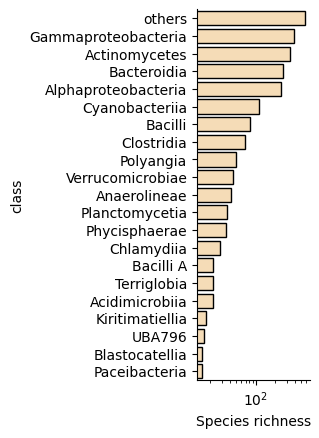

In [40]:
g = plot_topN_rank(libraries, 'class', 20)
g.figure.set_size_inches(2, 4)
g.axes[0, 0].set_xscale('log')
g.savefig("../figures/rankplot.richness-byclass.svg")

#### Calculation of class-level abundances

To compute class level abundances:
1. We count the total number of rows under the de-replicated list `[gtdb_id, habitat, site_code]` -> A
2. We count the total number of rows of the index by site -> B
3. We merge A and B by ´site_code´
4. We divide the count of A by the count in B.

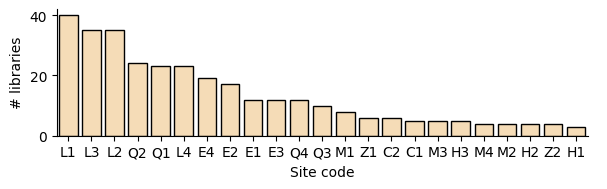

In [41]:
g = sns.catplot(
    data=libraries.value_counts(subset=['Site_code', 'library']).reset_index().value_counts('Site_code').reset_index(),
    x='Site_code', y='count', kind='bar', height=2.0, aspect=3.0, color='navajowhite', edgecolor='black'
)
g.set_xlabels("Site code")
g.set_ylabels("# libraries")

In [42]:
rank = 'class'
N = 20
A = libraries.value_counts(['gtdb_id', 'Habitat', 'Site_code', rank]).reset_index()
B = libraries.value_counts(['Site_code']).reset_index()
sites_ar = pd.merge(A, B, on='Site_code', suffixes=['', '_total'])
sites_ar['AR'] = sites_ar['count'] / sites_ar['count_total']
rank_counts = libraries.value_counts(['gtdb_id', rank]).reset_index().value_counts([rank]).reset_index()
topN_ranks = rank_counts[rank][:N].tolist()

sites_ar[f'top{N}_{rank}'] = sites_ar[rank].apply(lambda x: "others" if x not in topN_ranks else x)
sites_ar[f'rank{N}_{rank}'] = sites_ar[rank].apply(lambda x: topN_ranks.index(x) if x in topN_ranks else 21)

In [43]:
sites_ar

,gtdb_id,Habitat,Site_code,class,count,count_total,AR,top20_class,rank20_class
0,55151,Edge,L1,Bacilli,40,3176,0.012594,Bacilli,5
1,69364,Edge,L1,Verrucomicrobiae,40,3176,0.012594,Verrucomicrobiae,8
2,95757,Edge,L1,Gammaproteobacteria,40,3176,0.012594,Gammaproteobacteria,0
3,71277,Edge,L1,Clostridia,40,3176,0.012594,Clostridia,6
4,108293,Edge,L1,Bacilli,40,3176,0.012594,Bacilli,5
...,...,...,...,...,...,...,...,...,...
8794,75871,Oak,Q2,Bacteroidia,1,2705,0.000370,Bacteroidia,2
8795,75826,Edge,L2,Cyanobacteriia,1,2749,0.000364,Cyanobacteriia,4
8796,75766,Wasteland,E3,Gammaproteobacteria,1,1785,0.000560,Gammaproteobacteria,0
8797,75766,Wasteland,E1,Gammaproteobacteria,1,1447,0.000691,Gammaproteobacteria,0


In [44]:
topN_classes = sites_ar.groupby(f'top{N}_{rank}', as_index=False)['AR'].sum().sort_values(by='AR', ascending=False)
topN_classes['rAR'] = topN_classes['AR'] / len(libraries['Site_code'].unique())

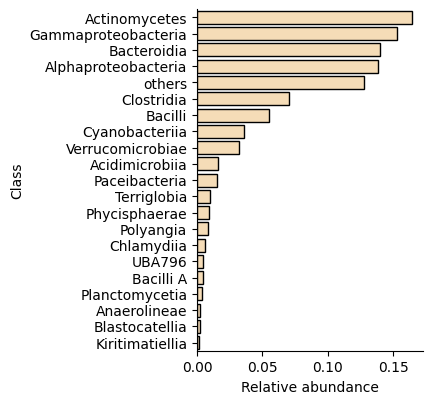

In [45]:
g = sns.catplot(data=topN_classes, y=f'top{N}_{rank}', x='rAR', kind='bar', color='navajowhite', edgecolor='black')
g.figure.set_size_inches(4, 4)
# g.axes[0, 0].set_xscale('log')
g.set_xlabels("Relative abundance")
g.set_ylabels("Class")
# g.savefig("../figures/rankplot.richness-byclass.svg")

#### Computing alpha-diversity metrics

We use the metrics as defined in Scikit-Bio

##### Shannon-entropy

In [46]:
from skbio.diversity.alpha import shannon

In [47]:
shannon_entropy = sites_ar.groupby([rank, 'Site_code', 'Habitat'], as_index=False)['AR'].sum().groupby(['Site_code', 'Habitat'])['AR'].apply(lambda x: shannon(x)).reset_index().rename(columns={'AR': "Shannon"})

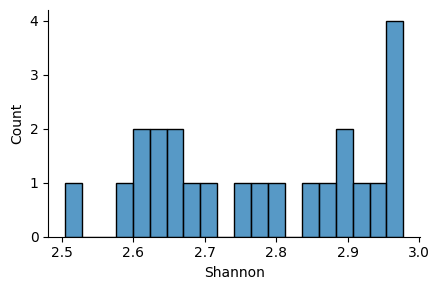

In [48]:
sns.displot(data=shannon_entropy, x='Shannon',height=3.0, aspect=1.5, edgecolor='black', bins=20)

**Figure X**. Histogram of Shannon entropies. 
- We cannot assume that this is a normal distribution.


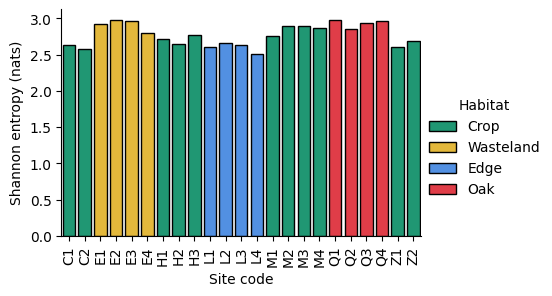

In [49]:
g = sns.catplot(data=shannon_entropy, x='Site_code', y='Shannon', kind='bar',hue='Habitat', palette=habitat_palette, height=3.0, aspect=1.5, edgecolor='black')
g.set_ylabels("Shannon entropy (nats)")
g.set_xticklabels(rotation=90)
g.set_xlabels("Site code")
# g.savefig("../figures/barplot.diversity.svg")

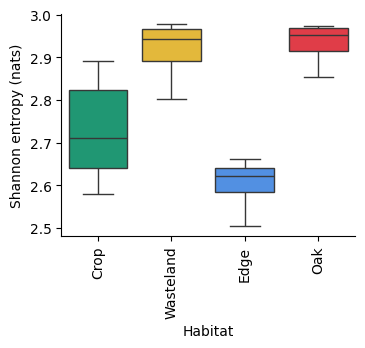

In [50]:
g = sns.catplot(data=shannon_entropy, x='Habitat', y='Shannon', kind='box',hue='Habitat', palette=habitat_palette, aspect=1.25, height=3.0)
g.set_ylabels("Shannon entropy (nats)")
g.set_xticklabels(rotation=90)
# g.savefig("../figures/barplot.diversity.svg")



Our hypothesis:
- **H0**: The site-diversity is the same across habitats.
- **H1**: The site-diversity is different across habitats.

Our samples Shannon-diversity is continuous but probably not normal. Therefore, we will have to run 

In [51]:
kw_h, pval = kruskal(
    shannon_entropy.query('Habitat == "Crop"')['Shannon'].values,
    shannon_entropy.query('Habitat == "Edge"')['Shannon'].values,
    shannon_entropy.query('Habitat == "Wasteland"')['Shannon'].values,
    shannon_entropy.query('Habitat == "Oak"')['Shannon'].values
)
significative = pval < 0.05
print(f"Kruskal-Willis H: {kw_h:8.4f}, p-val: {pval:8.4f}, significative: {significative}")

Kruskal-Willis H:  13.7406, p-val:   0.0033, significative: True


#### Chao-1 diversity

In [52]:
from skbio.diversity.alpha import chao1

In [53]:
chao1_diversity = sites_ar.groupby([rank, 'Site_code', 'Habitat'], as_index=False)['count'].sum().groupby(['Site_code', 'Habitat'])['count'].apply(lambda x: chao1(x)).reset_index().rename(columns={'count': "Chao1"})

In [54]:
chao1_diversity

,Site_code,Habitat,Chao1
0,C1,Crop,52.111111
1,C2,Crop,76.000000
2,E1,Wasteland,156.909091
3,E2,Wasteland,142.333333
4,E3,Wasteland,154.272727
5,E4,Wasteland,140.600000
6,H1,Crop,48.600000
7,H2,Crop,59.125000
8,H3,Crop,70.000000
9,L1,Edge,104.000000


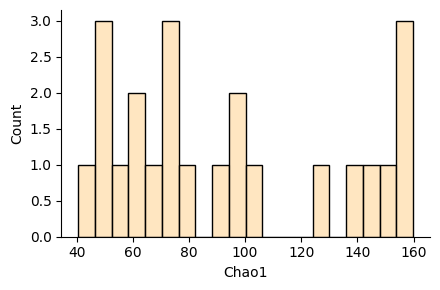

In [55]:
sns.displot(data=chao1_diversity, x='Chao1',height=3.0, aspect=1.5, edgecolor='black', bins=20, color='navajowhite',)

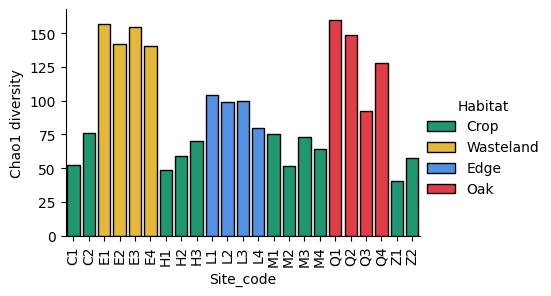

In [56]:
g = sns.catplot(data=chao1_diversity, x='Site_code', y='Chao1', kind='bar',hue='Habitat', palette=habitat_palette, height=3.0, aspect=1.5, edgecolor='black')
g.set_ylabels("Chao1 diversity")
g.set_xticklabels(rotation=90)
# g.savefig("../figures/barplot.diversity.svg")

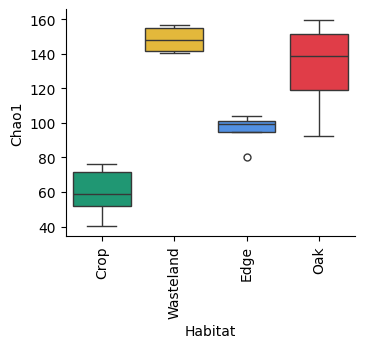

In [57]:
g = sns.catplot(data=chao1_diversity, x='Habitat', y='Chao1', kind='box',hue='Habitat', palette=habitat_palette, aspect=1.25, height=3.0)
g.set_ylabels("Chao1")
g.set_xticklabels(rotation=90)
# g.savefig("../figures/barplot.diversity.svg")

In [58]:
kw_h, pval = kruskal(
    chao1_diversity.query('Habitat == "Crop"')['Chao1'].values,
    chao1_diversity.query('Habitat == "Edge"')['Chao1'].values,
    chao1_diversity.query('Habitat == "Wasteland"')['Chao1'].values,
    chao1_diversity.query('Habitat == "Oak"')['Chao1'].values
)
significative = pval < 0.05
print(f"Kruskal-Willis H: {kw_h:8.4f}, p-val: {pval:8.4f}, significative: {significative}")

Kruskal-Willis H:  18.0109, p-val:   0.0004, significative: True


### Diversity (Faith's phylogenetic distance)

In [59]:
from skbio.diversity.alpha import faith_pd
from skbio import TreeNode

In [ ]:
libraries = pd.read_json("../results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json").rename(columns={'taxid': "gtdb_id"}).dropna(subset=['species'])
tree = TreeNode.read("../data/taxonomy/bac120.tree")
tree_tip_names = list(tree.subset())
mapping_genomes = pd.read_csv("../data/taxonomy/gtdb-taxdump/mapping_genomes", header=None, sep="\t", names=['genome', 'gtdb_id'])
mapping_genomes['genome'] = mapping_genomes['genome'].apply(lambda x: x.replace("_", " "))
mapping_genomes['is_tip'] = mapping_genomes['genome'].isin(tree_tip_names)
mapping_genomes = mapping_genomes.query('is_tip == True')[['genome', 'gtdb_id']].copy()
mapping_genomes
libraries = pd.merge(libraries, mapping_genomes, on='gtdb_id')
libraries

,genome,gtdb_id
6968,RS GCF 003697165.2,8
53945,RS GCF 000742135.1,10
64572,RS GCF 001027105.1,16
84636,RS GCF 000006945.2,18
95138,RS GCF 001457635.1,22
...,...,...
584377,GB GCA 029982795.1,137841
584378,RS GCF 902491705.1,137842
584379,RS GCF 003955665.1,137843
584380,GB GCA 023264155.1,137844


In [78]:
rank = 'class'
N = 20
A = libraries.value_counts(['gtdb_id', 'Habitat', 'Site_code', 'genome', rank]).reset_index()
B = libraries.value_counts(['Site_code']).reset_index()
sites_ar_g = pd.merge(A, B, on='Site_code', suffixes=['', '_total'])
sites_ar_g['AR'] = sites_ar['count'] / sites_ar['count_total']

In [84]:
faith_pd_df = sites_ar_g.groupby(['Site_code', 'Habitat'])[['count', 'genome']].apply(lambda x: faith_pd(x['count'], x['genome'], tree)).reset_index().rename(columns={0: "F-PD"})

In [85]:
faith_pd_df

,Site_code,Habitat,F-PD
0,C1,Crop,107.089434
1,C2,Crop,108.173729
2,E1,Wasteland,227.914450
3,E2,Wasteland,251.213072
4,E3,Wasteland,265.915702
5,E4,Wasteland,246.720847
6,H1,Crop,70.691755
7,H2,Crop,95.295182
8,H3,Crop,124.065160
9,L1,Edge,203.778029


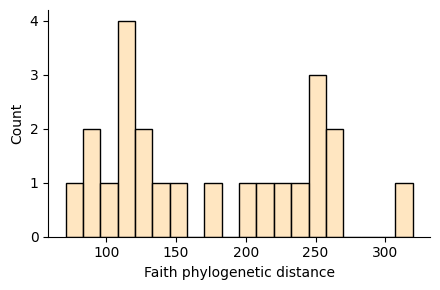

In [86]:
g = sns.displot(data=faith_pd_df, x='F-PD',height=3.0, aspect=1.5, edgecolor='black', bins=20, color='navajowhite',)
g.set_xlabels("Faith phylogenetic distance")

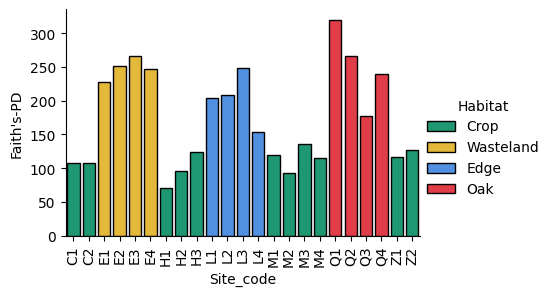

In [87]:
g = sns.catplot(data=faith_pd_df, x='Site_code', y='F-PD', kind='bar',hue='Habitat', palette=habitat_palette, height=3.0, aspect=1.5, edgecolor='black')
g.set_ylabels("Faith's-PD")
g.set_xticklabels(rotation=90)
# g.savefig("../figures/barplot.diversity.svg")

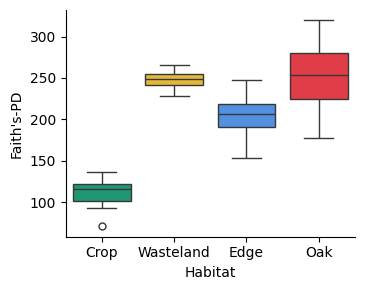

In [70]:
g = sns.catplot(data=faith_pd_df, x='Habitat', y='F-PD', kind='box',hue='Habitat', palette=habitat_palette, aspect=1.25, height=3.0)
g.set_ylabels("Faith's-PD")
# g.set_xticklabels(rotation=90)
# g.savefig("../figures/barplot.diversity.svg")

In [88]:
kw_h, pval = kruskal(
    faith_pd_df.query('Habitat == "Crop"')['F-PD'].values,
    faith_pd_df.query('Habitat == "Edge"')['F-PD'].values,
    faith_pd_df.query('Habitat == "Wasteland"')['F-PD'].values,
    faith_pd_df.query('Habitat == "Oak"')['F-PD'].values
)
significative = pval < 0.05
print(f"Kruskal-Willis H: {kw_h:8.4f}, p-val: {pval:8.4f}, significative: {significative}")

Kruskal-Willis H:  17.3152, p-val:   0.0006, significative: True


### All toghether 

Now we will try to check whether this diversity indicators are related to each other.

In [72]:
all_diversity_indicators = pd.merge(pd.merge(shannon_entropy, chao1_diversity, on=['Site_code', 'Habitat']), faith_pd_df, on=['Site_code', 'Habitat'])

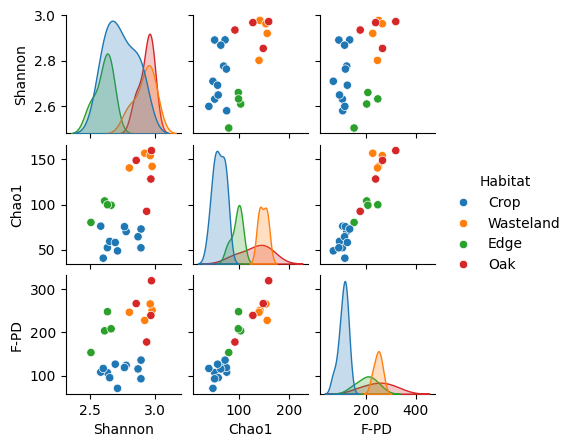

In [73]:
g = sns.pairplot(data=all_diversity_indicators.drop(columns=['Site_code']), hue='Habitat', height=1.5)

In [74]:
model = smf.ols('Chao1 ~ F_PD', data=all_diversity_indicators.rename(columns={'F-PD': 'F_PD'})).fit()
print(model.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.874   
Dependent Variable: Chao1            AIC:                188.8406
Date:               2025-04-30 15:55 BIC:                191.1116
No. Observations:   23               Log-Likelihood:     -92.420 
Df Model:           1                F-statistic:        153.1   
Df Residuals:       21               Prob (F-statistic): 4.12e-11
R-squared:          0.879            Scale:              198.27  
------------------------------------------------------------------
              Coef.   Std.Err.     t     P>|t|    [0.025    0.975]
------------------------------------------------------------------
Intercept     3.9265    7.8936   0.4974  0.6241  -12.4891  20.3422
F_PD          0.5186    0.0419  12.3742  0.0000    0.4315   0.6058
-----------------------------------------------------------------
Omnibus:               2.743        Durbin-Watson:          1.093
Prob(Omnibus):        

In [75]:
model = smf.ols('Shannon ~ F_PD', data=all_diversity_indicators.rename(columns={'F-PD': 'F_PD'})).fit()
print(model.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.190   
Dependent Variable: Shannon          AIC:                -25.0299
Date:               2025-04-30 15:55 BIC:                -22.7589
No. Observations:   23               Log-Likelihood:     14.515  
Df Model:           1                F-statistic:        6.162   
Df Residuals:       21               Prob (F-statistic): 0.0216  
R-squared:          0.227            Scale:              0.018150
-------------------------------------------------------------------
             Coef.    Std.Err.      t      P>|t|    [0.025   0.975]
-------------------------------------------------------------------
Intercept    2.6026     0.0755   34.4611   0.0000   2.4456   2.7597
F_PD         0.0010     0.0004    2.4824   0.0216   0.0002   0.0018
-----------------------------------------------------------------
Omnibus:               2.348        Durbin-Watson:          1.021
Prob(Omnibus):   

In [76]:
model = smf.ols('Chao1 ~ Shannon', data=all_diversity_indicators.rename(columns={'F-PD': 'F_PD'})).fit()
print(model.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.300   
Dependent Variable: Chao1            AIC:                228.2080
Date:               2025-04-30 15:55 BIC:                230.4790
No. Observations:   23               Log-Likelihood:     -112.10 
Df Model:           1                F-statistic:        10.44   
Df Residuals:       21               Prob (F-statistic): 0.00400 
R-squared:          0.332            Scale:              1098.0  
-----------------------------------------------------------------
               Coef.   Std.Err.    t    P>|t|    [0.025   0.975] 
-----------------------------------------------------------------
Intercept    -328.8425 131.2231 -2.5060 0.0205 -601.7359 -55.9492
Shannon       152.4987  47.1936  3.2313 0.0040   54.3542 250.6433
-----------------------------------------------------------------
Omnibus:               6.773        Durbin-Watson:          1.316
Prob(Omnibus):         0.03